# GPD via Peaks-Over-Threshold

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_gpd_pot.ipynb)

This notebook walks the canonical **peaks-over-threshold (POT)** pipeline. Instead of one observation per year (the block-maxima approach of the previous three notebooks), POT keeps *every* exceedance over a high threshold $u$ and models the conditional excesses with a Generalized Pareto Distribution.

POT is the workhorse parameterisation in finance, hydrology and reliability whenever you have *more data than you would get from annual maxima alone* — which is essentially always.

**What we cover**

1. **Theory.** The Pickands–Balkema–de Haan theorem; the GPD log-likelihood; threshold-stability and the mean-residual-life plot.
2. **Threshold selection.** `quantile_threshold` at the 95th percentile, plus a sensitivity sweep to show how the posterior on $\xi$ depends on $u$.
3. **Declustering.** Why naïve POT fails on temporally correlated data, and how `decluster_runs` enforces independence.
4. **Bayesian fit.** NumPyro NUTS over $(\sigma, \xi)$ with weakly informative priors.
5. **Return levels.** The Poisson-GPD compound that gives the per-year return level.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax.distributions import GeneralizedParetoDistribution
from xtremax.extraction import decluster_runs, quantile_threshold


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,xarray,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
numpy     : 2.4.4
matplotlib: 3.10.8
numpyro   : 0.19.0
xarray    : 2026.4.0
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Pickands–Balkema–de Haan and the GPD

Suppose $X_1, X_2, \ldots$ are i.i.d. from a parent CDF $F$ in the GEVD domain of attraction with shape $\xi$. Define the **conditional excess distribution** at threshold $u$:

$$
F_u(y) \;:=\; \mathbb{P}(X - u \le y \mid X > u) \;=\; \frac{F(u + y) - F(u)}{1 - F(u)},\qquad y \ge 0.
$$

The Pickands–Balkema–de Haan (1974/1975) theorem says: there exists a positive function $\sigma_u$ such that, as $u$ approaches the right endpoint $x_F$,

$$
\sup_{0 \le y < x_F - u} \bigl| F_u(y) - H(y;\,\sigma_u, \xi) \bigr| \;\xrightarrow[u \to x_F]{} \;0,
$$

where $H$ is the Generalized Pareto CDF

$$
H(y;\,\sigma, \xi) \;=\;
\begin{cases}
1 - \bigl(1 + \xi y/\sigma\bigr)^{-1/\xi}, & \xi \neq 0, \\[4pt]
1 - e^{-y/\sigma}, & \xi = 0,
\end{cases}
$$

defined on $y \ge 0$ (and additionally $y \le -\sigma/\xi$ if $\xi < 0$).

**Three crucial implications.**

1. **The shape parameter is shared.** The $\xi$ in the GPD is the *same* $\xi$ that appears in the GEVD limit of $F$. Block-maxima fits and POT fits should agree on $\xi$ (and they often do — that is a nice sanity check).
2. **Threshold stability.** If $X - u_1$ is GPD with parameters $(\sigma_{u_1}, \xi)$ and $u_2 > u_1$, then $X - u_2$ is also GPD with the *same* $\xi$ and shifted scale

   $$
   \sigma_{u_2} \;=\; \sigma_{u_1} + \xi(u_2 - u_1).
   $$

   A non-trivial slope of $\sigma_u$ vs $u$ in fitted parameters is a sign that the asymptotic POT regime has not kicked in — *raise the threshold*.
3. **The mean excess is linear.** Define $e(u) := \mathbb{E}[X - u \mid X > u]$. For a GPD with $\xi < 1$,

   $$
   e(u) \;=\; \frac{\sigma + \xi u}{1 - \xi},
   $$

   a *linear* function of the threshold. The empirical mean-excess plot should therefore be linear above the asymptotic threshold — a famous diagnostic.

**Log-likelihood.** Given exceedances $y_1, \ldots, y_k$,

$$
\ell(\sigma, \xi) \;=\; -k\,\log\sigma \;-\; \bigl(1/\xi + 1\bigr)\sum_{i=1}^{k} \log\!\bigl(1 + \xi y_i/\sigma\bigr).
$$

This is what `GeneralizedParetoDistribution.log_prob` evaluates inside NumPyro.

## 2. Synthetic temporally correlated daily series

We build a daily-stage process with: a smooth seasonal cycle, AR(1) persistence (so adjacent days are correlated — *not* i.i.d.), and Gaussian noise. POT pretends the exceedances are independent; we will see how this assumption fails on the raw series and how `decluster_runs` fixes it.

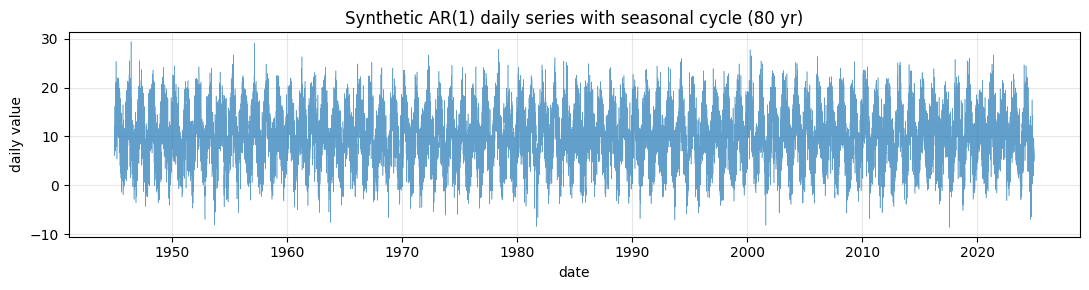

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)

dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
day_of_year = (dates.dayofyear - 1).to_numpy()
seasonal = 5.0 * np.sin(2 * np.pi * day_of_year / DAYS_PER_YEAR)

# AR(1) noise with persistence rho=0.6 — neighbouring days are correlated.
rho = 0.6
innovation = RNG.normal(0.0, 1.0, size=n)
ar1 = np.empty(n)
ar1[0] = innovation[0]
for t in range(1, n):
    ar1[t] = rho * ar1[t - 1] + innovation[t]
ar1 *= np.sqrt(1.0 - rho**2) * 4.0  # rescale to ~unit-variance times σ
daily = 10.0 + seasonal + ar1

series = xr.DataArray(daily, dims="time", coords={"time": dates})

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(series.time, series.values, lw=0.4, alpha=0.7, color="tab:blue")
ax.set_title("Synthetic AR(1) daily series with seasonal cycle (80 yr)")
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Threshold selection at the 95th percentile

95th percentile threshold u = 18.774
Raw (non-declustered) exceedances: 1460


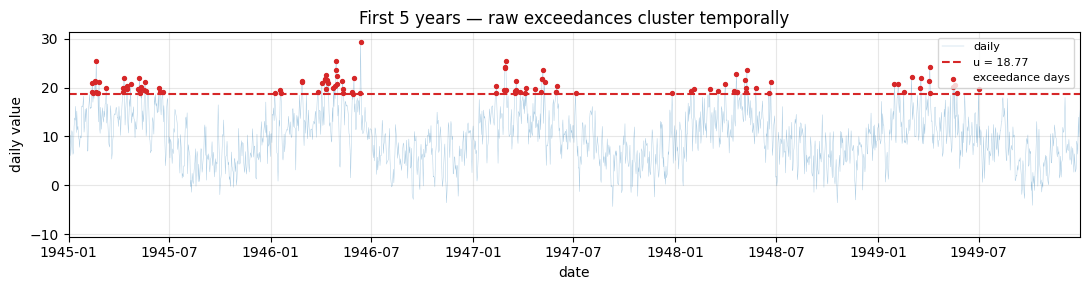

In [5]:
u = float(quantile_threshold(series, 0.95))
print(f"95th percentile threshold u = {u:.3f}")

raw_exceedances = (series.where(series > u) - u).dropna("time")
print(f"Raw (non-declustered) exceedances: {raw_exceedances.sizes['time']}")

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(series.time, series.values, lw=0.3, alpha=0.4, color="tab:blue", label="daily")
ax.axhline(u, color="tab:red", lw=1.5, ls="--", label=f"u = {u:.2f}")
ax.scatter(
    raw_exceedances.time,
    raw_exceedances.values + u,
    color="tab:red",
    s=8,
    zorder=3,
    label="exceedance days",
)
ax.set_xlim(series.time.values[0], series.time.values[365 * 5])
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.set_title("First 5 years — raw exceedances cluster temporally")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Why declustering matters

The plot above shows the issue. Adjacent exceedance days come from the *same* extreme weather event, and they are highly correlated — fitting a GPD to all of them violates the i.i.d. assumption and produces a spuriously narrow posterior. The classical fix is the **runs method**: collapse each contiguous run of exceedances into a single "event" (typically the maximum within the run), keeping only one observation per cluster.

In [6]:
declustered = decluster_runs(series, threshold=u, reduction="max")
declustered_excess = declustered.dropna("time") - u
print(f"Declustered exceedances: {declustered_excess.sizes['time']}")
print(
    f"Cluster reduction:       "
    f"{raw_exceedances.sizes['time']} → {declustered_excess.sizes['time']} "
    f"({100 * declustered_excess.sizes['time'] / raw_exceedances.sizes['time']:.1f}%)"
)

excess = jnp.asarray(declustered_excess.values)

Declustered exceedances: 847
Cluster reduction:       1460 → 847 (58.0%)


## 4. Mean-residual-life (mean-excess) plot

The mean-excess function $e(u) = \mathbb{E}[X - u \mid X > u]$ should be **linear in $u$** above the asymptotic threshold. We plot the empirical $\hat e(u)$ over a sweep of candidate thresholds; we want to identify a value above which the curve is roughly linear.

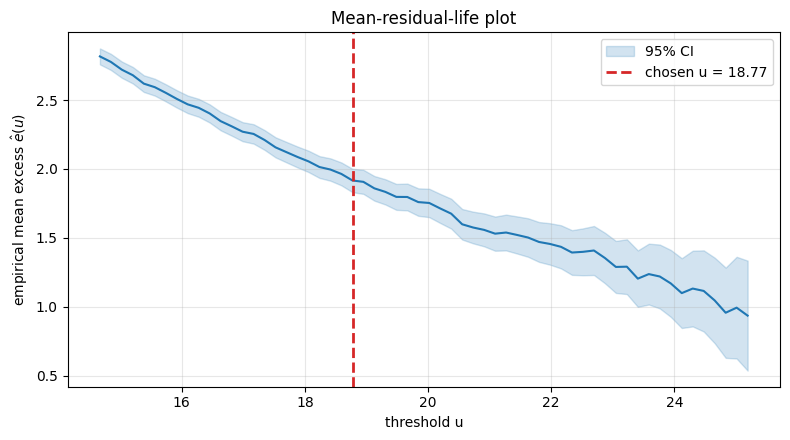

In [7]:
threshold_grid = np.linspace(np.quantile(daily, 0.80), np.quantile(daily, 0.999), 60)
mean_excess = []
n_above = []
ci_half_width = []
for u_test in threshold_grid:
    above = daily[daily > u_test] - u_test
    if len(above) > 5:
        mean_excess.append(above.mean())
        n_above.append(len(above))
        ci_half_width.append(1.96 * above.std(ddof=1) / np.sqrt(len(above)))
    else:
        mean_excess.append(np.nan)
        n_above.append(0)
        ci_half_width.append(np.nan)
mean_excess = np.asarray(mean_excess)
ci_half_width = np.asarray(ci_half_width)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(threshold_grid, mean_excess, color="tab:blue")
ax.fill_between(
    threshold_grid,
    mean_excess - ci_half_width,
    mean_excess + ci_half_width,
    alpha=0.2,
    color="tab:blue",
    label="95% CI",
)
ax.axvline(u, color="tab:red", lw=2, ls="--", label=f"chosen u = {u:.2f}")
ax.set_xlabel("threshold u")
ax.set_ylabel(r"empirical mean excess $\hat e(u)$")
ax.set_title("Mean-residual-life plot")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Reading this:

- **Linear region** above some threshold: the asymptotic GPD regime has kicked in. The slope is $\xi/(1-\xi)$ and the intercept is $\sigma_0/(1-\xi)$.
- **Curved or noisy region** below: the threshold is too low (non-tail observations contaminate) or above (variance is too high — fewer data).
- The plotted 95% confidence band widens to the right because the right-tail samples thin out; this is the *small-sample* end.

The chosen $u$ should sit comfortably inside the linear region and have enough exceedances above it for a stable fit — there is genuine art here, and the plot is a sanity check, not a recipe.

## 5. Bayesian GPD fit

**Model.** With independent declustered excesses $y_i = z_i - u$,

$$
y_i \mid \sigma, \xi \;\sim\; \mathrm{GPD}(\sigma, \xi).
$$

**Priors.**
- $\sigma \sim \mathrm{HalfNormal}(2 \bar y)$, where $\bar y$ is the empirical mean excess. Half-normal is positive; the scale is comfortably wider than any plausible value.
- $\xi \sim \mathcal{N}(0, 0.25)$, a weakly informative prior covering the physically reasonable range $[-0.5, +0.5]$.

In [8]:
sigma_loc = float(jnp.mean(excess))


def gpd_model(excess, sigma_prior_scale):
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale * 2))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample(
        "obs",
        GeneralizedParetoDistribution(scale=sigma, concentration=xi),
        obs=excess,
    )


kernel = NUTS(gpd_model, target_accept_prob=0.95, init_strategy=init_to_median)
mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False)
mcmc.run(KEY, excess=excess, sigma_prior_scale=sigma_loc)
mcmc.print_summary(prob=0.95)
posterior = mcmc.get_samples()

/tmp/ipykernel_2854516/3419348543.py:15: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False)



                mean       std    median      2.5%     97.5%     n_eff     r_hat
     sigma      2.54      0.11      2.54      2.33      2.74   1013.37      1.00
        xi     -0.18      0.03     -0.19     -0.23     -0.13   1001.08      1.00

Number of divergences: 3


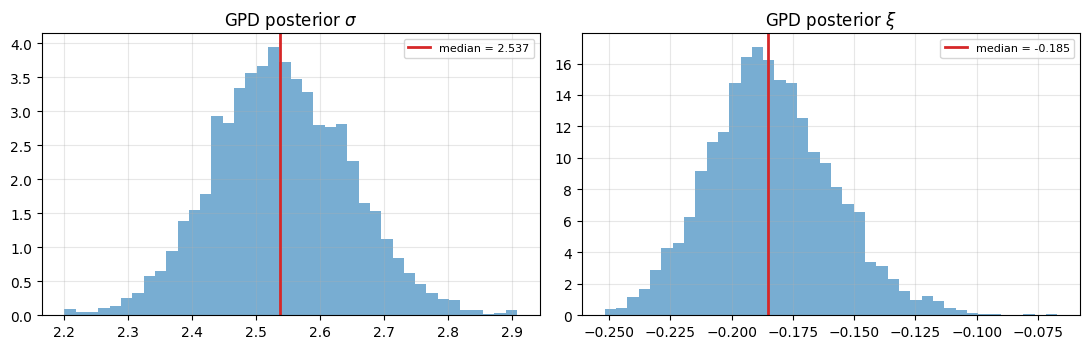

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, name, samples in zip(
    axes,
    ["sigma", "xi"],
    [posterior["sigma"], posterior["xi"]],
    strict=True,
):
    ax.hist(np.asarray(samples), bins=40, density=True, color="tab:blue", alpha=0.6)
    ax.axvline(
        float(jnp.median(samples)),
        color="tab:red",
        lw=2,
        label=f"median = {float(jnp.median(samples)):.3f}",
    )
    ax.set_title(rf"GPD posterior $\{name}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Threshold-sensitivity sweep

How robust is the inference to the choice of $u$? We re-fit the GPD at a sweep of candidate thresholds and plot the posterior median (with 95% CI) of $\xi$ as a function of $u$. **Threshold stability** says $\xi$ should be approximately constant above the asymptotic threshold; a flat plateau is evidence that the chosen $u$ is in the right regime.

/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


/tmp/ipykernel_2854516/1475597988.py:32: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(kernel_t, num_warmup=600, num_samples=800, num_chains=2,


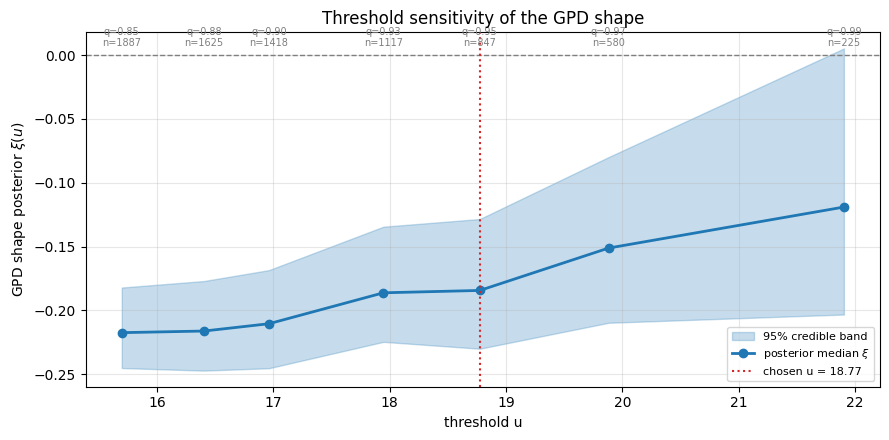

In [10]:
def fit_at_threshold(u_test, key):
    excess_t = (
        declustered_runs := decluster_runs(series, threshold=u_test, reduction="max")
    )
    excess_t = declustered_runs.dropna("time") - u_test
    if excess_t.sizes["time"] < 30:
        return None
    excess_t = jnp.asarray(excess_t.values)
    s_loc = float(jnp.mean(excess_t))
    kernel_t = NUTS(gpd_model, target_accept_prob=0.95, init_strategy=init_to_median)
    mcmc_t = MCMC(
        kernel_t, num_warmup=600, num_samples=800, num_chains=2, progress_bar=False
    )
    mcmc_t.run(key, excess=excess_t, sigma_prior_scale=s_loc)
    return mcmc_t.get_samples()


sweep_quantiles = [0.85, 0.88, 0.90, 0.93, 0.95, 0.97, 0.99]
sweep_us = [float(quantile_threshold(series, q)) for q in sweep_quantiles]
sweep_keys = jax.random.split(KEY, len(sweep_us))
sweep_xi_med = []
sweep_xi_lo = []
sweep_xi_hi = []
sweep_n = []
for u_test, k in zip(sweep_us, sweep_keys, strict=True):
    decl = decluster_runs(series, threshold=u_test, reduction="max")
    excess_t_da = decl.dropna("time") - u_test
    excess_t = jnp.asarray(excess_t_da.values)
    sweep_n.append(int(excess_t_da.sizes["time"]))
    s_loc = float(jnp.mean(excess_t))
    kernel_t = NUTS(gpd_model, target_accept_prob=0.95, init_strategy=init_to_median)
    mcmc_t = MCMC(
        kernel_t, num_warmup=600, num_samples=800, num_chains=2, progress_bar=False
    )
    mcmc_t.run(k, excess=excess_t, sigma_prior_scale=s_loc)
    s = mcmc_t.get_samples()["xi"]
    sweep_xi_med.append(float(jnp.median(s)))
    sweep_xi_lo.append(float(jnp.quantile(s, 0.025)))
    sweep_xi_hi.append(float(jnp.quantile(s, 0.975)))

sweep_xi_med = np.asarray(sweep_xi_med)
sweep_xi_lo = np.asarray(sweep_xi_lo)
sweep_xi_hi = np.asarray(sweep_xi_hi)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(
    sweep_us,
    sweep_xi_lo,
    sweep_xi_hi,
    alpha=0.25,
    color="tab:blue",
    label="95% credible band",
)
ax.plot(
    sweep_us,
    sweep_xi_med,
    color="tab:blue",
    marker="o",
    lw=2,
    label=r"posterior median $\xi$",
)
ax.axhline(0, color="tab:gray", lw=1, ls="--")
ax.axvline(u, color="tab:red", lw=1.5, ls=":", label=f"chosen u = {u:.2f}")
for u_test, q, ndecl in zip(sweep_us, sweep_quantiles, sweep_n, strict=True):
    ax.annotate(
        f"q={q:.2f}\nn={ndecl}",
        xy=(u_test, ax.get_ylim()[1]),
        xytext=(0, -10),
        textcoords="offset points",
        ha="center",
        fontsize=7,
        color="tab:gray",
    )
ax.set_xlabel("threshold u")
ax.set_ylabel(r"GPD shape posterior $\xi(u)$")
ax.set_title("Threshold sensitivity of the GPD shape")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

A *flat* curve says the asymptotic regime has kicked in and the chosen threshold sits in a stable region. A *trending* curve says you should pick a higher threshold (until the trend disappears or until the credible band blows up from too-few-exceedances). For our AR(1) Gaussian-tail process we expect $\xi \approx 0$ across the upper plateau.

## 7. Return levels via Poisson–GPD compound

A pure GPD models *excess sizes*, not the *frequency* of exceedances. To get the per-year return level you need the **rate** $\lambda_u$ of exceedances per year and combine the two as

$$
z_T \;=\; u + \frac{\sigma}{\xi}\Bigl[(T \lambda_u)^{\xi} - 1\Bigr], \qquad \xi \neq 0,
$$

i.e. "the level exceeded with probability $1/(T \lambda_u)$ given a threshold exceedance." We use the *empirical* declustered rate

$$
\hat\lambda_u \;=\; \text{(declustered exceedances)} / \text{(years of data)}.
$$

Declustered events per year: λ_u = 10.59


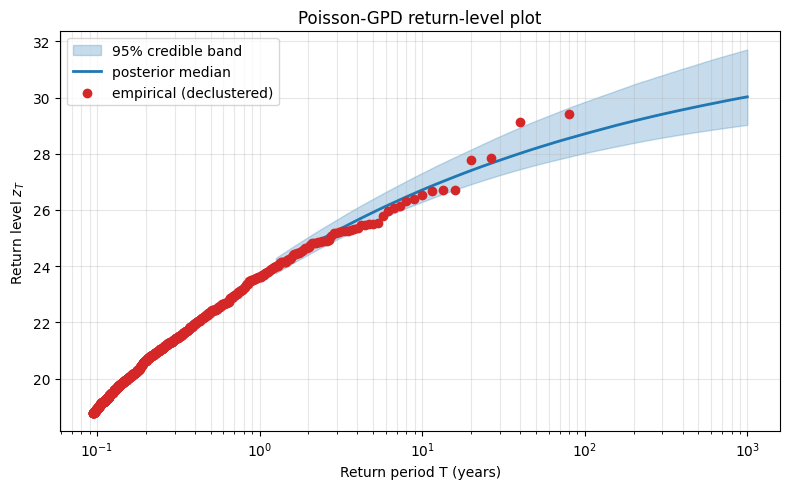

100-year return level (posterior median): 28.72
95% credible interval:                    [28.04, 29.86]


In [11]:
years_of_data = (series.time.values[-1] - series.time.values[0]) / np.timedelta64(
    365, "D"
)
lambda_u = declustered_excess.sizes["time"] / years_of_data
print(f"Declustered events per year: λ_u = {lambda_u:.2f}")

periods = jnp.logspace(0.1, 3, 80)


def rl_pot(sigma, xi, T, u_val, lam):
    Tlam = T * lam
    safe_xi = jnp.where(jnp.abs(xi) < 1e-7, 1.0, xi)
    return jnp.where(
        jnp.abs(xi) < 1e-7,
        u_val + sigma * jnp.log(Tlam),
        u_val + (sigma / safe_xi) * (jnp.power(Tlam, safe_xi) - 1.0),
    )


rl_samples = jax.vmap(lambda s, x: rl_pot(s, x, periods, u, lambda_u))(
    posterior["sigma"], posterior["xi"]
)

# Empirical (Weissman) plotting positions for declustered exceedances
sorted_excess = np.sort(np.asarray(excess))
m = len(sorted_excess)
emp_periods = 1.0 / (lambda_u * (1 - np.arange(1, m + 1) / (m + 1)))

med = jnp.median(rl_samples, axis=0)
lo = jnp.quantile(rl_samples, 0.025, axis=0)
hi = jnp.quantile(rl_samples, 0.975, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(
    periods, lo, hi, alpha=0.25, color="tab:blue", label="95% credible band"
)
ax.plot(periods, med, color="tab:blue", lw=2, label="posterior median")
ax.scatter(
    emp_periods,
    sorted_excess + u,
    color="tab:red",
    zorder=3,
    label="empirical (declustered)",
)
ax.set_xscale("log")
ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Return level $z_T$")
ax.set_title("Poisson-GPD return-level plot")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

idx_100 = int(jnp.argmin(jnp.abs(periods - 100.0)))
print(f"100-year return level (posterior median): {float(med[idx_100]):.2f}")
print(
    f"95% credible interval:                    "
    f"[{float(lo[idx_100]):.2f}, {float(hi[idx_100]):.2f}]"
)

## 8. PP plot for the GPD fit

Same diagnostic as for the GEVD: order the excesses $y_{(1)} \le \ldots \le y_{(k)}$, plot $\hat F(y_{(i)})$ vs $i/(k+1)$.

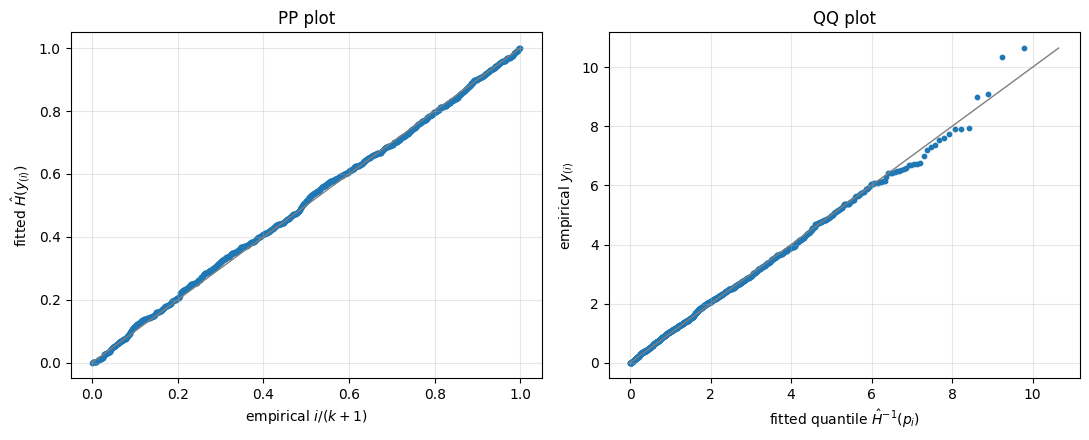

In [12]:
sigma_med = float(jnp.median(posterior["sigma"]))
xi_med = float(jnp.median(posterior["xi"]))
fitted_gpd = GeneralizedParetoDistribution(scale=sigma_med, concentration=xi_med)
sorted_excess_jx = jnp.asarray(sorted_excess)
emp_p = (np.arange(1, m + 1)) / (m + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot([0, 1], [0, 1], color="tab:gray", lw=1)
axes[0].scatter(
    emp_p, np.asarray(fitted_gpd.cdf(sorted_excess_jx)), color="tab:blue", s=10
)
axes[0].set_xlabel("empirical $i/(k+1)$")
axes[0].set_ylabel(r"fitted $\hat H(y_{(i)})$")
axes[0].set_title("PP plot")
axes[0].grid(True, alpha=0.3)


# numpyro's GPD doesn't expose icdf, so build it from the closed form.
def gpd_quantile(p, sigma, xi):
    if abs(xi) < 1e-7:
        return -sigma * np.log(1 - p)
    return (sigma / xi) * ((1 - p) ** (-xi) - 1.0)


q_fit = np.asarray([gpd_quantile(p, sigma_med, xi_med) for p in emp_p])
mn, mx = sorted_excess.min(), sorted_excess.max()
axes[1].plot([mn, mx], [mn, mx], color="tab:gray", lw=1)
axes[1].scatter(q_fit, sorted_excess, color="tab:blue", s=10)
axes[1].set_xlabel(r"fitted quantile $\hat H^{-1}(p_i)$")
axes[1].set_ylabel(r"empirical $y_{(i)}$")
axes[1].set_title("QQ plot")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

- **POT uses every exceedance, not just one per year.** With AR(1) data and a 95th-percentile threshold we get hundreds of declustered events; the GPD posterior is correspondingly tight.
- **Decluster *before* fitting.** Naïve POT on raw exceedances violates i.i.d. and produces a falsely narrow posterior. `decluster_runs` collapses each contiguous run into one event.
- **Validate the threshold.** The mean-residual-life plot and the threshold-sensitivity sweep both target the same question — *is $u$ high enough that the asymptotic regime has kicked in?* — and give complementary visual answers.
- **Return levels need a rate.** GPD on its own has no per-year scale; the Poisson-GPD compound multiplies the exceedance rate $\lambda_u$ into the return-period formula.

The next notebook generalises threshold selection to *non-stationary* data via `XarrayQuantileRegressor`, fitting a covariate-dependent threshold and feeding the residual exceedances into the same GPD.